In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")


C:\Users\kavin\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:

# Load the dataset
df = pd.read_csv("D:\\Projects\\EDA Agri project\\crop_yield.csv")

# Display the first few rows
df.head()


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


Shape of dataset: (19689, 10)

Data types:
Crop                object
Crop_Year            int64
Season              object
State               object
Area               float64
Production           int64
Annual_Rainfall    float64
Fertilizer         float64
Pesticide          float64
Yield              float64
dtype: object


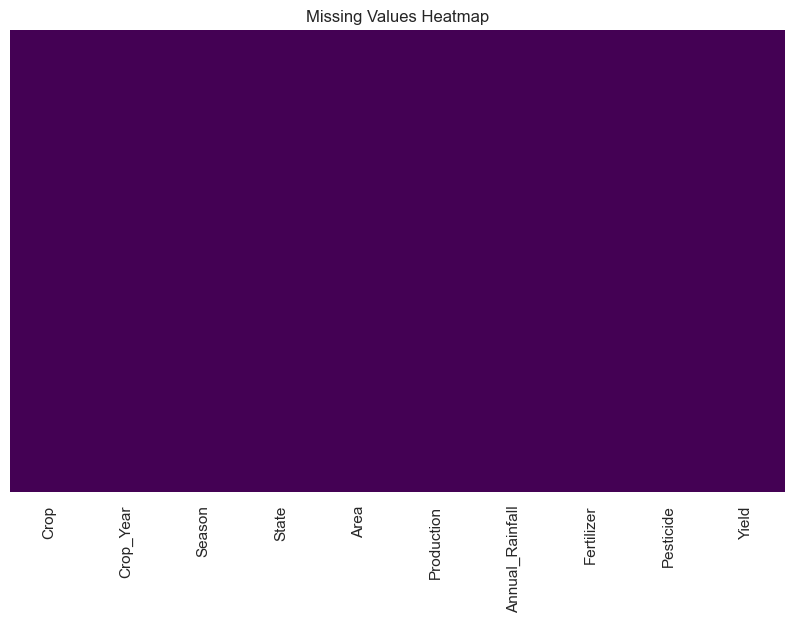

Number of duplicate rows: 0


In [3]:
print("Shape of dataset:", df.shape)
print("\nData types:")
print(df.dtypes)

df.describe()

# Check for missing values
df.isnull().sum()

plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()


# Impute or drop missing values as needed
df = df.dropna()  # or use df.fillna() for imputation

print("Number of duplicate rows:", df.duplicated().sum())



In [4]:
# Save the original data before encoding
original_df = df.copy()


In [5]:
# Identify categorical columns from the original dataset
categorical_cols = original_df.select_dtypes(include=['object', 'category']).columns.tolist()
print(categorical_cols)

['Crop', 'Season', 'State']


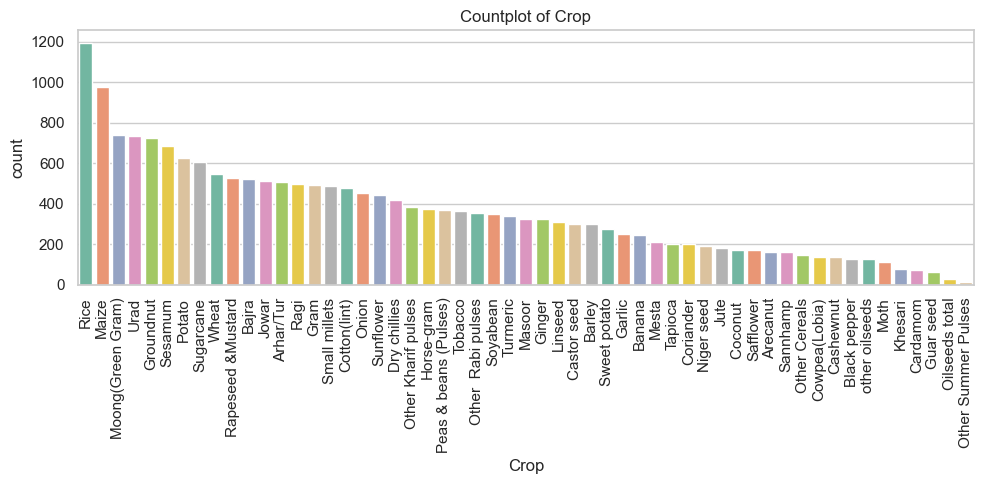

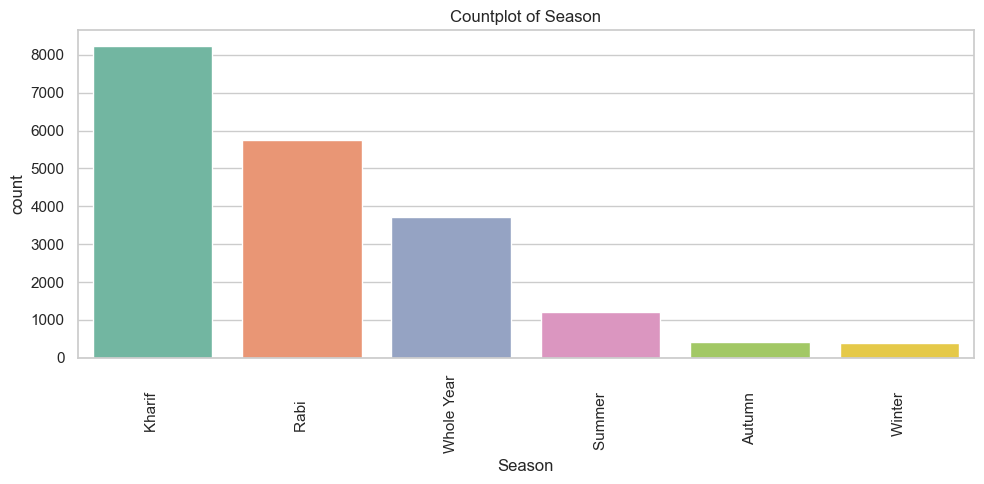

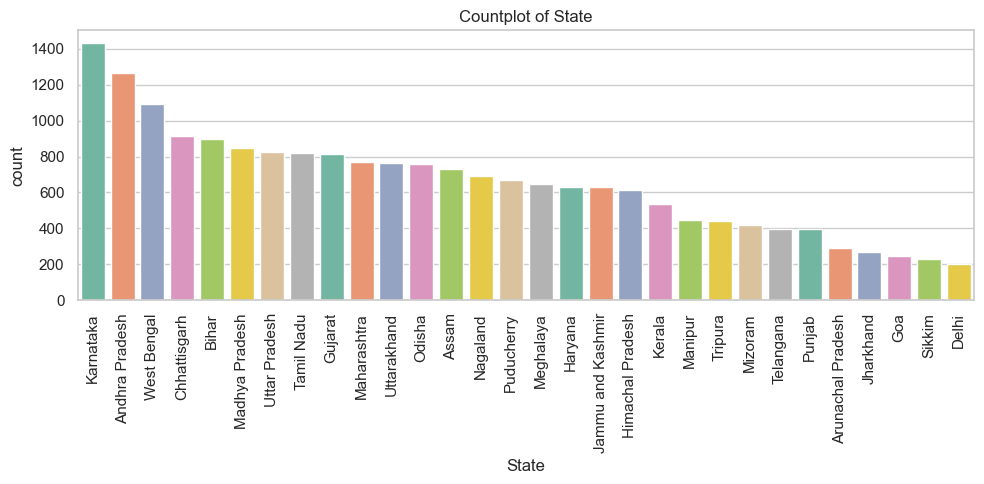

In [6]:
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=original_df, x=col, order=original_df[col].value_counts().index, palette="Set2")
    plt.xticks(rotation=90)
    plt.title(f"Countplot of {col}")
    plt.tight_layout()
    plt.show()

In [7]:
# One-hot encode categorical columns and store in a new DataFrame
df = pd.get_dummies(df, drop_first=True)

C:\Users\kavin\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


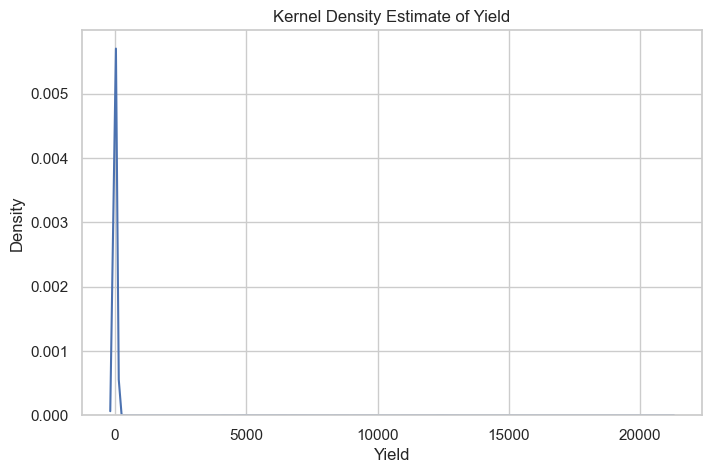

In [8]:
plt.figure(figsize=(8, 5))
sns.kdeplot(df['Yield'], bw_adjust=0.5)
plt.title("Kernel Density Estimate of Yield")
plt.xlabel("Yield")
plt.ylabel("Density")
plt.show()


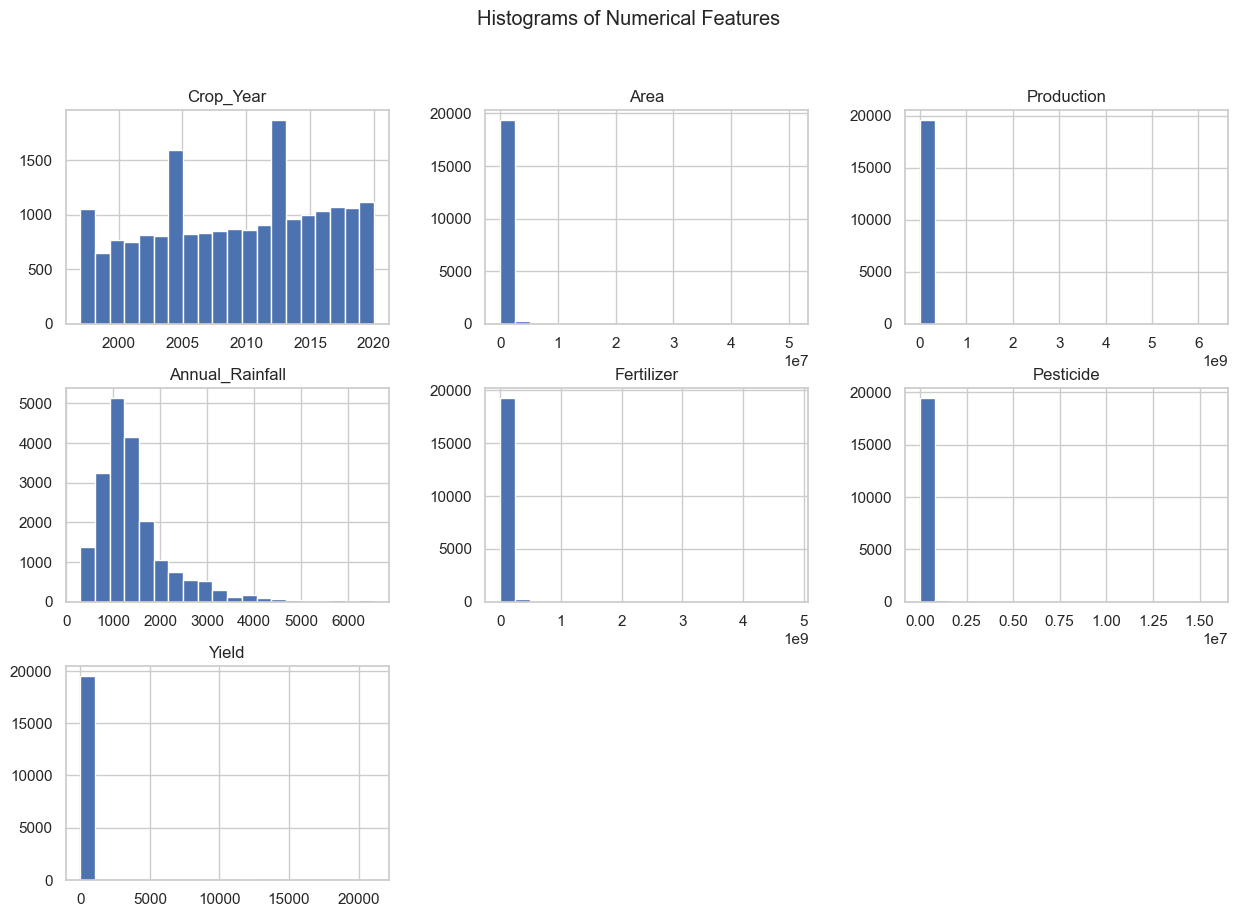

In [9]:
df.hist(bins=20, figsize=(15, 10))
plt.suptitle("Histograms of Numerical Features")
plt.show()


In [10]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'Yield' in numerical_cols:
    numerical_cols.remove('Yield')
print("Numerical columns:", numerical_cols)


Numerical columns: ['Crop_Year', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide']


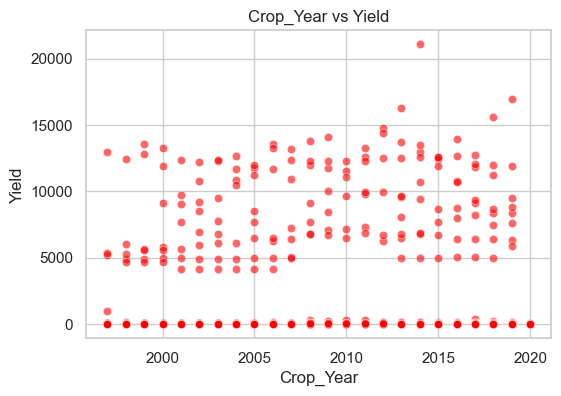

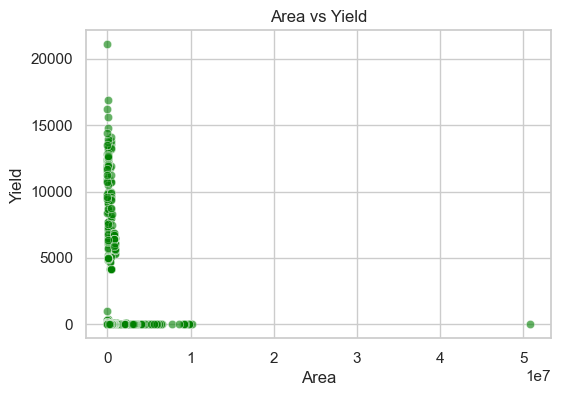

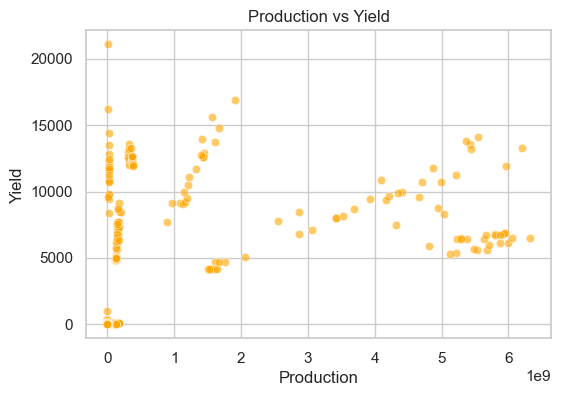

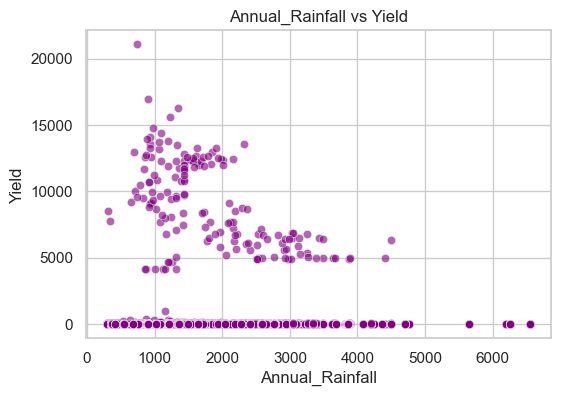

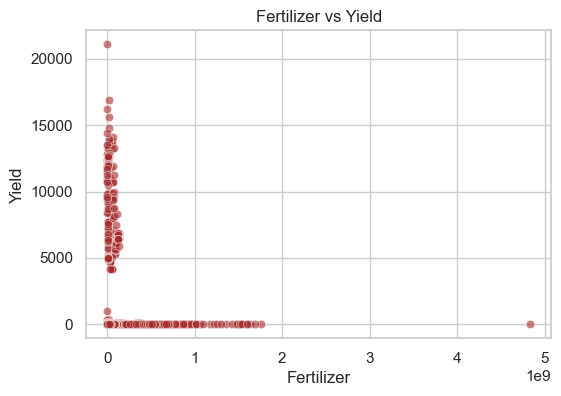

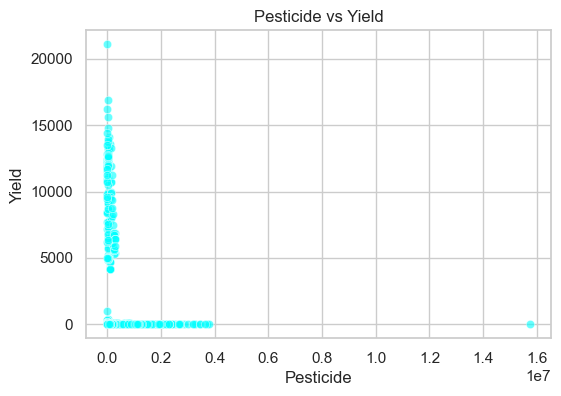

In [11]:
colors = ['red', 'green', 'orange', 'purple', 'brown', 'cyan', 'magenta']

for i, col in enumerate(numerical_cols):
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=col, y='Yield', color=colors[i % len(colors)], alpha=0.6)
    plt.title(f"{col} vs Yield")
    plt.show()


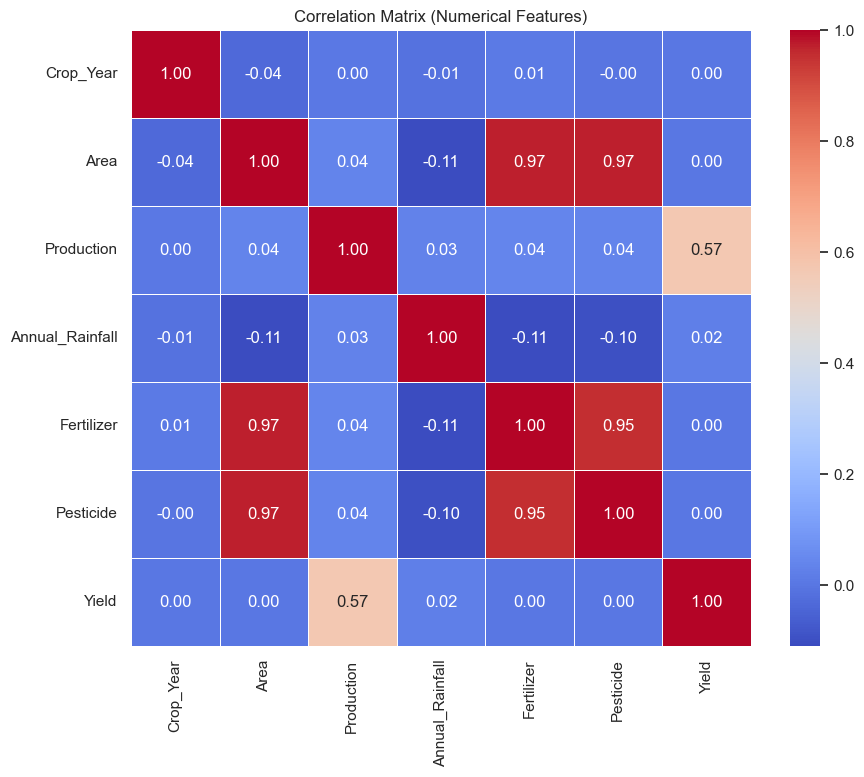

In [12]:

# Select only numerical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Compute correlation matrix
corr = df[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix (Numerical Features)")
plt.show()


In [9]:
# Define features and target
X = df.drop(columns=['Yield'])  # Replace 'TargetColumn' with the actual target column name
y = df['Yield']


In [10]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
from sklearn.linear_model import LinearRegression

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [12]:
from sklearn.metrics import mean_squared_error, r2_score

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate MSE and R²
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R² Score: {r2}')


Mean Squared Error: 158461.92759737236
R² Score: 0.8022291019986482


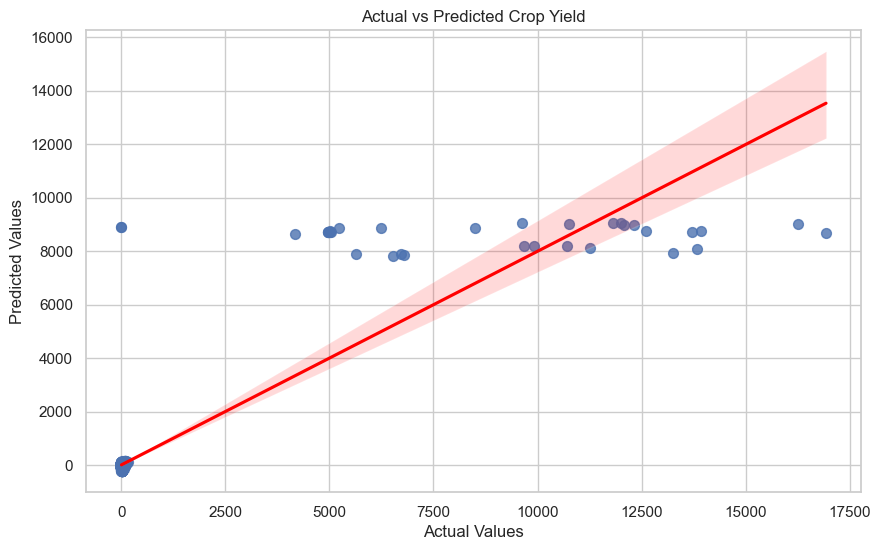

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot actual vs predicted
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'s': 50}, line_kws={'color': 'red'})
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Crop Yield')
plt.show()


In [9]:
import pandas as pd

# Ask user to input values
crop = input("Enter crop name (e.g., Wheat): ")
crop_year = int(input("Enter crop year (e.g., 2020): "))
season = input("Enter season (e.g., Kharif, Rabi): ")
state = input("Enter state (e.g., Punjab): ")
area = float(input("Enter area in hectares: "))
production = float(input("Enter production in metric tons: "))
rainfall = float(input("Enter annual rainfall in mm: "))
fertilizer = float(input("Enter fertilizer used in kg: "))
pesticide = float(input("Enter pesticide used in kg: "))

# Create DataFrame from input
input_data = {
    'Crop': [crop],
    'Crop_Year': [crop_year],
    'Season': [season],
    'State': [state],
    'Area': [area],
    'Production': [production],
    'Annual_Rainfall': [rainfall],
    'Fertilizer': [fertilizer],
    'Pesticide': [pesticide]
}

input_df = pd.DataFrame(input_data)

# Preprocessing: One-hot encoding and aligning columns with training data
input_df = pd.get_dummies(input_df)

# Ensure all expected columns exist
input_df = input_df.reindex(columns=X.columns, fill_value=0)

# Predict yield
predicted_yield = model.predict(input_df)

print(f"\nPredicted Crop Yield: {predicted_yield[0]:.2f}")


Enter crop name (e.g., Wheat): Onion
Enter crop year (e.g., 2020): 2002
Enter season (e.g., Kharif, Rabi): Whole Year
Enter state (e.g., Punjab): Tamil Nadu
Enter area in hectares: 23492
Enter production in metric tons: 198715
Enter annual rainfall in mm: 315.9
Enter fertilizer used in kg: 2223987.64
Enter pesticide used in kg: 5873

Predicted Crop Yield: 7.69


In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize with reduced complexity and parallel processing
model1 = RandomForestRegressor(
    n_estimators=200,    # fewer trees
    max_depth=15,       # limit tree depth
 # consider fewer features at each split
    n_jobs=-1,          # use all CPU cores
    random_state=42
)

# Train
model1.fit(X_train, y_train)

# Predict
y_pred = model1.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Random Forest Regression (Faster)")
print("MSE:", mse)
print("R²:", r2)


Random Forest Regression (Faster)
MSE: 10568.913239381603
R²: 0.9868093018055302


In [23]:
import pandas as pd

# Ask user to input values
crop = input("Enter crop name (e.g., Wheat): ")
crop_year = int(input("Enter crop year (e.g., 2020): "))
season = input("Enter season (e.g., Kharif, Rabi): ")
state = input("Enter state (e.g., Punjab): ")
area = float(input("Enter area in hectares: "))
production = float(input("Enter production in metric tons: "))
rainfall = float(input("Enter annual rainfall in mm: "))
fertilizer = float(input("Enter fertilizer used in kg: "))
pesticide = float(input("Enter pesticide used in kg: "))

# Create DataFrame from input
input_data = {
    'Crop': [crop],
    'Crop_Year': [crop_year],
    'Season': [season],
    'State': [state],
    'Area': [area],
    'Production': [production],
    'Annual_Rainfall': [rainfall],
    'Fertilizer': [fertilizer],
    'Pesticide': [pesticide]
}

input_df = pd.DataFrame(input_data)

# Preprocessing: One-hot encoding and aligning columns with training data
input_df = pd.get_dummies(input_df)

# Ensure all expected columns exist
input_df = input_df.reindex(columns=X.columns, fill_value=0)

# Predict yield
predicted_yield = model1.predict(input_df)

print(f"\nPredicted Crop Yield: {predicted_yield[0]:.2f}")


Enter crop name (e.g., Wheat): Wheat
Enter crop year (e.g., 2020): 2025
Enter season (e.g., Kharif, Rabi): Kharif
Enter state (e.g., Punjab): Punjab
Enter area in hectares: 5000
Enter production in metric tons: 123456
Enter annual rainfall in mm: 378.3
Enter fertilizer used in kg: 23478001
Enter pesticide used in kg: 25689

Predicted Crop Yield: 4.60


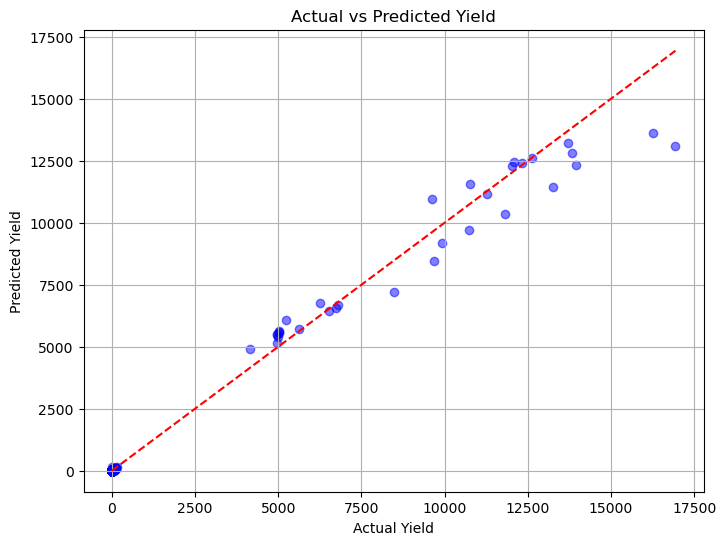

In [22]:
import matplotlib.pyplot as plt

# Predict using your model
y_pred = model1.predict(X_test)

# Create the plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # ideal line
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")
plt.grid(True)
plt.show()


In [13]:
from xgboost import XGBRegressor
model2 = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6,n_jobs=-1, random_state=42)
model2.fit(X_train, y_train)
y_pred = model2.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("XGBoost Regression")
print("MSE:", mse)
print("R²:", r2)


XGBoost Regression
MSE: 64979.63895053654
R²: 0.918901140848773


In [17]:
import pandas as pd

# Ask user to input values
crop = input("Enter crop name (e.g., Wheat): ")
crop_year = int(input("Enter crop year (e.g., 2020): "))
season = input("Enter season (e.g., Kharif, Rabi): ")
state = input("Enter state (e.g., Punjab): ")
area = float(input("Enter area in hectares: "))
production = float(input("Enter production in metric tons: "))
rainfall = float(input("Enter annual rainfall in mm: "))
fertilizer = float(input("Enter fertilizer used in kg: "))
pesticide = float(input("Enter pesticide used in kg: "))

# Create DataFrame from input
input_data = {
    'Crop': [crop],
    'Crop_Year': [crop_year],
    'Season': [season],
    'State': [state],
    'Area': [area],
    'Production': [production],
    'Annual_Rainfall': [rainfall],
    'Fertilizer': [fertilizer],
    'Pesticide': [pesticide]
}

input_df = pd.DataFrame(input_data)

# Preprocessing: One-hot encoding and aligning columns with training data
input_df = pd.get_dummies(input_df)

# Ensure all expected columns exist
input_df = input_df.reindex(columns=X.columns, fill_value=0)

# Predict yield
predicted_yield = model2.predict(input_df)

print(f"\nPredicted Crop Yield: {predicted_yield[0]:.2f}")


Enter crop name (e.g., Wheat): Onion
Enter crop year (e.g., 2020): 1997
Enter season (e.g., Kharif, Rabi): Whole Year
Enter state (e.g., Punjab): Assam
Enter area in hectares: 7832
Enter production in metric tons: 17943
Enter annual rainfall in mm: 2051.4
Enter fertilizer used in kg: 745371.44
Enter pesticide used in kg: 2427.92

Predicted Crop Yield: 5.32


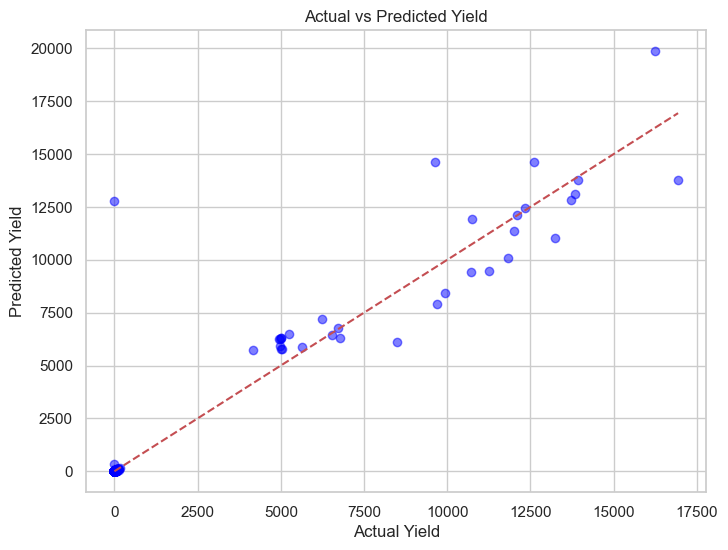

In [16]:
import matplotlib.pyplot as plt

# Predict using your model
y_pred = model2.predict(X_test)

# Create the plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # ideal line
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")
plt.grid(True)
plt.show()
